# Local Regression

Clara Hardes, 03.09.2026

In this file local regression is applied to investigate the relation between low income families and mortality rate. For that the variables 
- POOR (families with income <3000$) and 
- MORT (Total age-adjusted mortality rate per 100,000) 

of the dataset pollution_cleaneddata.csv were used. 

The parameters for the local regression were derived by minimizing the function:
 
$$
\sum_{i=1}^{k}
K_{i0}
\left(
y_i-\beta_0-\beta_1x_i
\right)^2
$$
    

In [2]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r'pollution_cleaneddata.csv')

In [20]:
def loess(x_0,x_values,y_values,k,plotting=True):

    '''
    Function that implements a local regression model and predicts y-values and standard error
    input:
        x_0 (list): a list of x values for which a prediction is going to be made
        x_values (pd.DataFrame): all x_values (in our case variables of 'POOR')
        y_values (pd.DataFrame): all y_values (in our case variables of 'MORT')
        k (int): The number of datapoints, that are considered 
        plotting (bool): if local regression should be plotted

    return:
        pred (list): list of predictions for x_0
        se (list): list of standard errors for local regressions of x_0s
    '''
    pred = []
    se = []
    y_plot = y_values.copy()
    y_plot[:] = np.nan
    if plotting:
        plt.figure()
        plt.scatter(x_values,y_values)  
    for x in x_0:
        dist = abs(x_values - x)
        nearest_indices = np.argsort(dist)[:k]
        x_nearest = x_values[nearest_indices]
        y_nearest = y_values[nearest_indices]
        #weights are calculated by the distance (bigger weights for more near datapoints)
        weights = 1 / (1 + dist[nearest_indices])
       
        # objective function for minimization algorithm
        def objective(param):
            intercept,slope= param
            error = np.sum(weights*((y_nearest - intercept - slope * x_nearest)**2))
            return error
        # 
        result = minimize(objective,x0=[0,0])
        intercept,slope = result.x
        pred.append(intercept + slope*x)
        y_pred = intercept + slope*x_nearest
    
        # the standard error is calculated by taking the square root of the mean of the squared error
        std_error = np.sqrt(np.mean((y_pred - y_nearest)**2))
        se.append(std_error)

        if plotting:
            # plot local regression line
            x_line = np.linspace(
            x_nearest.min(),
            x_nearest.max(),
            100
            )
            y_line = intercept + slope * x_line
            plt.plot(x_line, y_line, c='red',label=f'x_0 = {x}, y_pred = {pred[-1]:.2f}, se = {se[-1]:.2f}')    


    if plotting:
        plt.legend() 
        plt.title(f"Local Regression for x_0={x_0} and k={k}")
        plt.xlabel("POOR")
        plt.ylabel("MORT")
        plt.tight_layout()
        plt.show()

        
    # return predictions and standard errors   
    return pred,se

Predictions and standard errors for x_0 = [10, 18, 25] and k=1
PRED: [890.4468986122147, 957.8337691307727, 1010.2090029777631]
SE: [7.457856554538012e-08, 1.329312908637803e-07, 1.897062702482799e-07]
Predictions and standard errors for x_0 = [10, 18, 25] and k=2
PRED: [885.3833320434591, 934.1609560964262, 1062.216922097496]
SE: [4.441921128984383e-06, 2.2965833305381652e-05, 6.694564200110337e-06]
Predictions and standard errors for x_0 = [10, 18, 25] and k=3
PRED: [893.3535523098051, 947.8706996776023, 1043.8433100624934]
SE: [11.488155850191589, 5.617501154784448, 39.00526641588473]
Predictions and standard errors for x_0 = [10, 18, 25] and k=4
PRED: [885.2775110588079, 950.675994262896, 1032.9001598798231]
SE: [16.066704458743207, 8.01476303950178, 54.31157840013499]
Predictions and standard errors for x_0 = [10, 18, 25] and k=5
PRED: [895.676524004258, 968.2457695433143, 1026.522116524302]
SE: [42.25120704070759, 41.54955116960206, 49.17951177715423]
Predictions and standard err

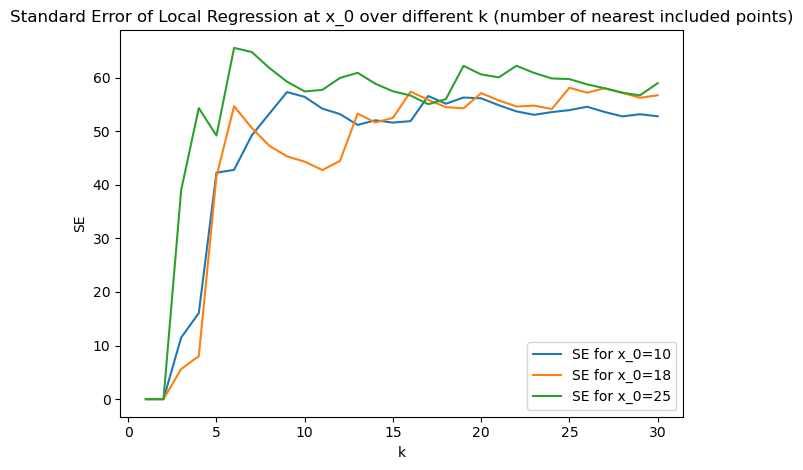

In [21]:
# select x- and y-values (families with income <3000$ (POOR) and Total age-adjusted mortality rate per 100,000 (MORT))
x_values = df['POOR']
y_values = df['MORT']
#the 10%, 18% and 25% of families with income <3000$ (POOR)
x_0 = [10,18,25]

se_10 = []
se_18 = []
se_25 = []
# estimating k
for k in range(1,31):
    # apply function based on k neares points and get predictions and standard errors
    pred,se = loess(x_0,x_values,y_values,k,plotting=False)
    se_10.append(se[0])
    se_18.append(se[1])
    se_25.append(se[2])
    print(f"Predictions and standard errors for x_0 = {x_0} and k={k}")
    print("PRED:",pred)
    print("SE:",se)
#plot se over k
plt.figure()
plt.title("Standard Error of Local Regression at x_0 over different k (number of nearest included points)")
plt.plot(range(1,31),se_10,label="SE for x_0=10")
plt.plot(range(1,31),se_18,label="SE for x_0=18")
plt.plot(range(1,31),se_25,label="SE for x_0=25")
plt.legend()
plt.xlabel("k")
plt.ylabel("SE")
plt.tight_layout()
plt.show()

From plotting the standard error of different k I decided to use k=11 as a balance between standard error and robustness.

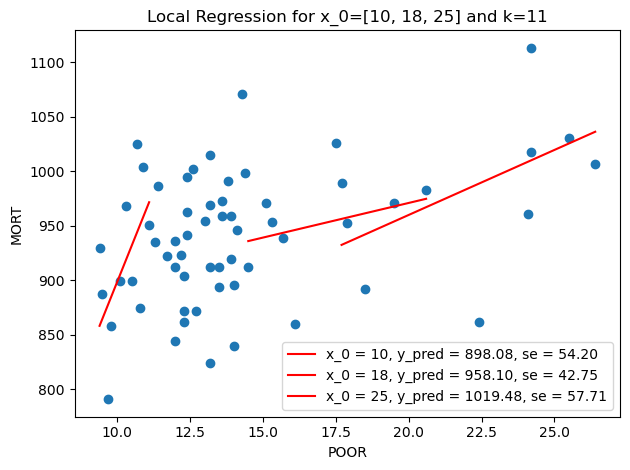

Predictions and standard errors for x_0 = [10,18,25] and k=11
PRED: [898.0796387570016, 958.0990284492284, 1019.481208469015]
SE: [54.20331354209611, 42.749506569153475, 57.71371007870029]


In [22]:
# select x- and y-values (families with income <3000$ (POOR) and Total age-adjusted mortality rate per 100,000 (MORT))
x_values = df['POOR']
y_values = df['MORT']
#the 10%, 18% and 25% of families with income <3000$ (POOR)
x_0 = [10,18,25]
# apply function based on 10 neares points (k=10) and get predictions and standard errors
pred,se = loess(x_0,x_values,y_values,11)
print("Predictions and standard errors for x_0 = [10,18,25] and k=11")
print("PRED:",pred)
print("SE:",se)

When considering the 11 nearest points, the predictions and standard errors for the mortality rate at 10%, 18%, and 25% of families with income < $3000 (POOR) are the following:

- **10%:** prediction ≈ 898, SE ≈ 54
- **18%:** prediction ≈ 958, SE ≈ 43
- **25%:** prediction ≈ 1020, SE ≈ 58